In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


![](https://static2.srcdn.com/wordpress/wp-content/uploads/2020/03/feature-image-1-1.jpg)

# 1.Introduction

**Importing Modules**

In [2]:
import numpy as np                     #Basically used for array manupulation
import pandas as pd                    #Operation in dataFrame
import matplotlib.pyplot as plt        #Plotting graph
import seaborn as sns                  #Creative Visualization
sns.set_style('darkgrid')

from sklearn.preprocessing import RobustScaler,OneHotEncoder,OrdinalEncoder  #Scale even with outlier
from sklearn.pipeline import Pipeline
from sklearn.model_selection  import cross_val_score,RepeatedStratifiedKFold
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LogisticRegression

**Loading Dataset**

In [3]:
train=pd.read_csv('/kaggle/input/titanic/train.csv',index_col='PassengerId')   #Train dataset
test=pd.read_csv('/kaggle/input/titanic/test.csv',index_col='PassengerId')     #Test dataset

data=pd.concat([train,test])          #Combing both train and test into a dataframe


# 2.**EDA**

In [4]:
print('Total no of nulls in train\n\n',train.isnull().sum(),end='\n\n\n')      #Null value in train dataset
print('Total no of nulls in test',test.isnull().sum())                         #Null value in test dataset

Total no of nulls in train

 Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64


Total no of nulls in test Pclass        0
Name          0
Sex           0
Age          86
SibSp         0
Parch         0
Ticket        0
Fare          1
Cabin       327
Embarked      0
dtype: int64


In [5]:
print('Description of train dataset:-')
(train.describe())                              #Description of train dataset

Description of train dataset:-


,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
print('Description of test dataset:-')
(test.describe())  

Description of test dataset:-


,Pclass,Age,SibSp,Parch,Fare
count,418.000000,332.000000,418.000000,418.000000,417.000000
mean,2.265550,30.272590,0.447368,0.392344,35.627188
std,0.841838,14.181209,0.896760,0.981429,55.907576
min,1.000000,0.170000,0.000000,0.000000,0.000000
25%,1.000000,21.000000,0.000000,0.000000,7.895800
50%,3.000000,27.000000,0.000000,0.000000,14.454200
75%,3.000000,39.000000,1.000000,0.000000,31.500000
max,3.000000,76.000000,8.000000,9.000000,512.329200


# 3.  Data Visualization

array([[<AxesSubplot:title={'center':'Survived'}>,
        <AxesSubplot:title={'center':'Pclass'}>],
       [<AxesSubplot:title={'center':'Age'}>,
        <AxesSubplot:title={'center':'SibSp'}>],
       [<AxesSubplot:title={'center':'Parch'}>,
        <AxesSubplot:title={'center':'Fare'}>]], dtype=object)

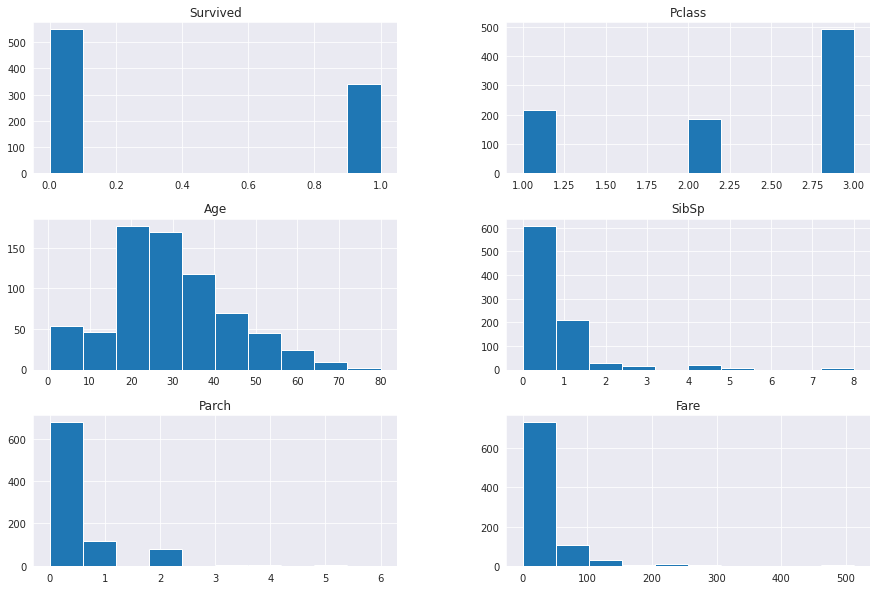

In [7]:
train.hist(figsize=(15,10))     #Visualiztion of every column

**Survived**

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning
/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning
/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning
/opt/conda/lib/python3.7/site-packages/seaborn

<AxesSubplot:xlabel='SibSp', ylabel='count'>

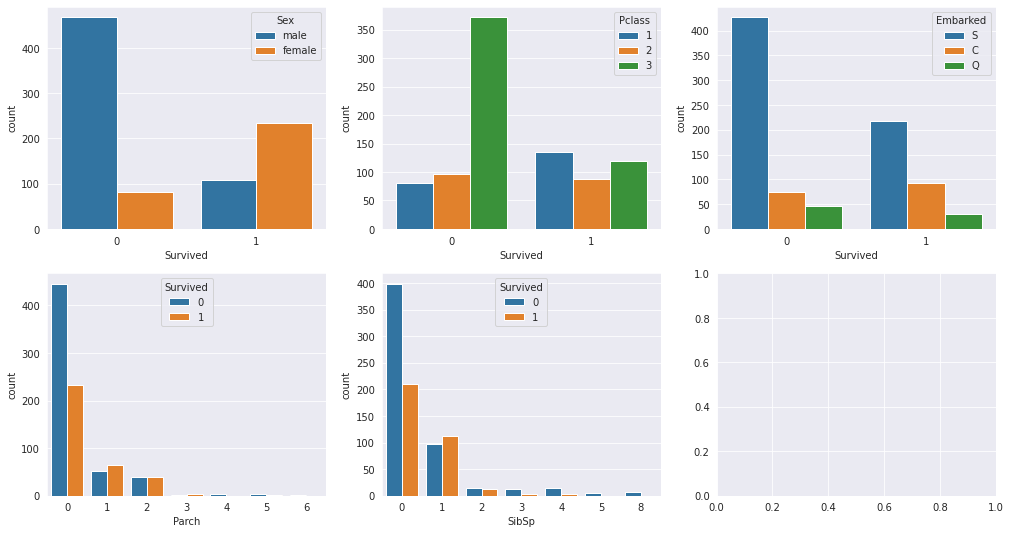

In [8]:
fig,ax=plt.subplots(2,3,figsize=(17,9))
sns.countplot(train['Survived'],ax=ax[0,0],hue=train['Sex'])         
sns.countplot(train['Survived'],ax=ax[0,1],hue=train['Pclass'])
sns.countplot(train['Survived'],ax=ax[0,2],hue=train['Embarked'])
sns.countplot(train['Parch'],ax=ax[1,0],hue=train['Survived'])
sns.countplot(train['SibSp'],ax=ax[1,1],hue=train['Survived'])

Conclusion:-
* Male has less chance to survive
* People from 3rd class has a less ratio to survive.
* People from southampton have a less chance to survive.
* People with 1 or no sibling has more chance to survive.

**Pclass**

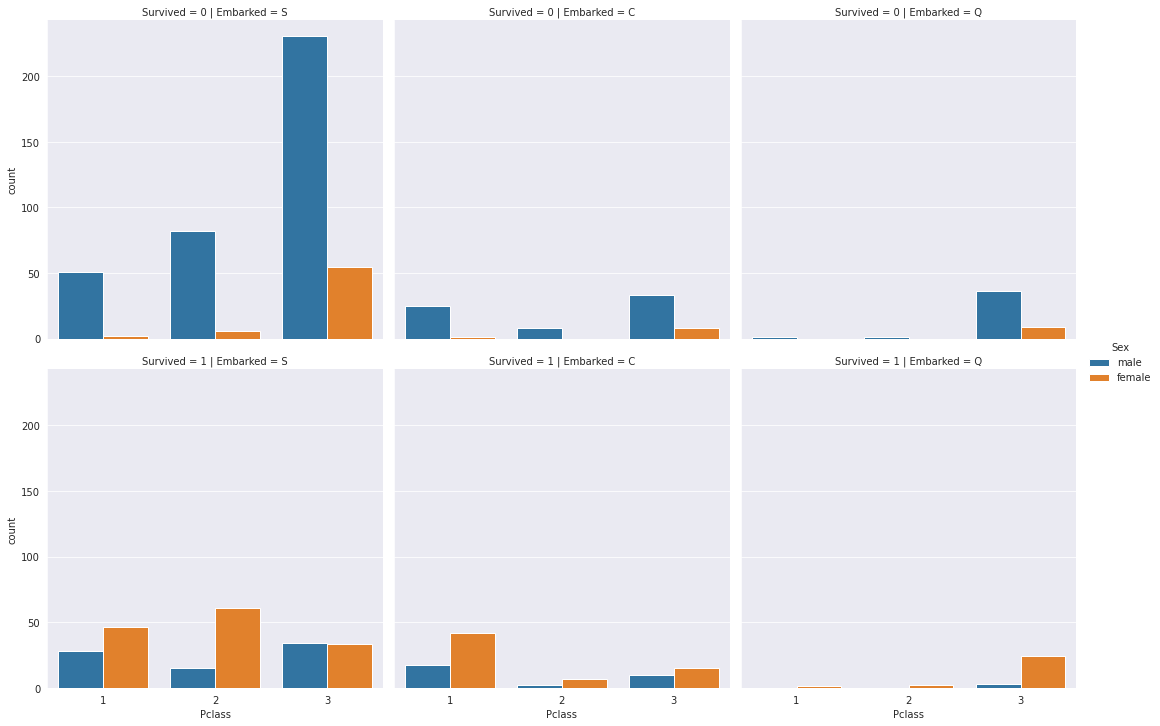

In [9]:
sns.catplot(x='Pclass',data=train,row='Survived',kind='count',col='Embarked',hue='Sex')


Conclusion:-
* Male from Southampton has less chance to survive.
* Women of 3rd class from 'Q' has more chance to survive.

**Age**

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


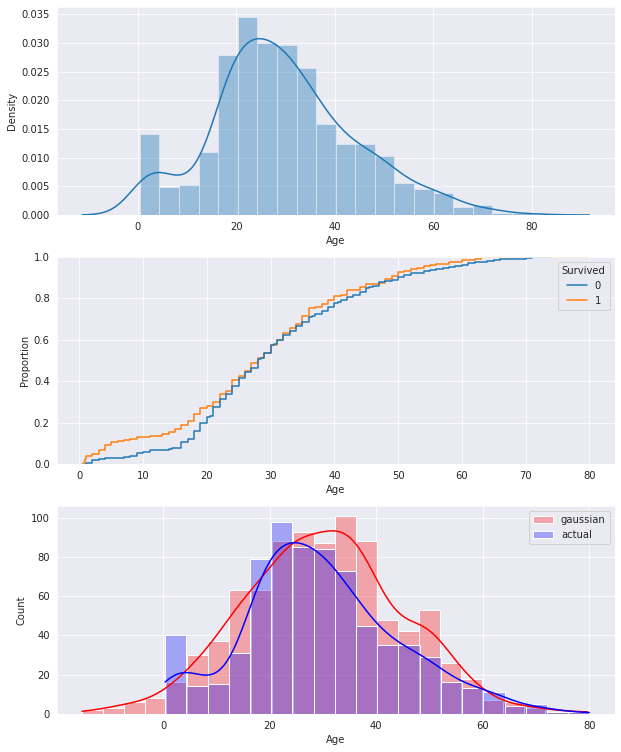

In [10]:
fig,ax=plt.subplots(3,figsize=(10,13))
sns.distplot(train['Age'],ax=ax[0])              # Actual histogram of Age
sns.ecdfplot(x='Age',data=train,ax=ax[1],hue='Survived')  #ECDF plot representation of age


#---------------------------------------------------------
std,mean=np.std(train['Age']),np.mean(train['Age'])    #Theotrical representation of Age column
gaussian_age=np.random.normal(mean,std,len(train))     # Actual representation of Age columns

sns.histplot(gaussian_age,ax=ax[2],color='red',alpha=0.3,kde=True,label='gaussian')
sns.histplot(train['Age'],ax=ax[2],color='blue',alpha=0.3,kde=True,label='actual')
plt.legend()

Conclusion:-
* In fig 1 there is a peak in age column showing children have more chance to survive.

**Fare**

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


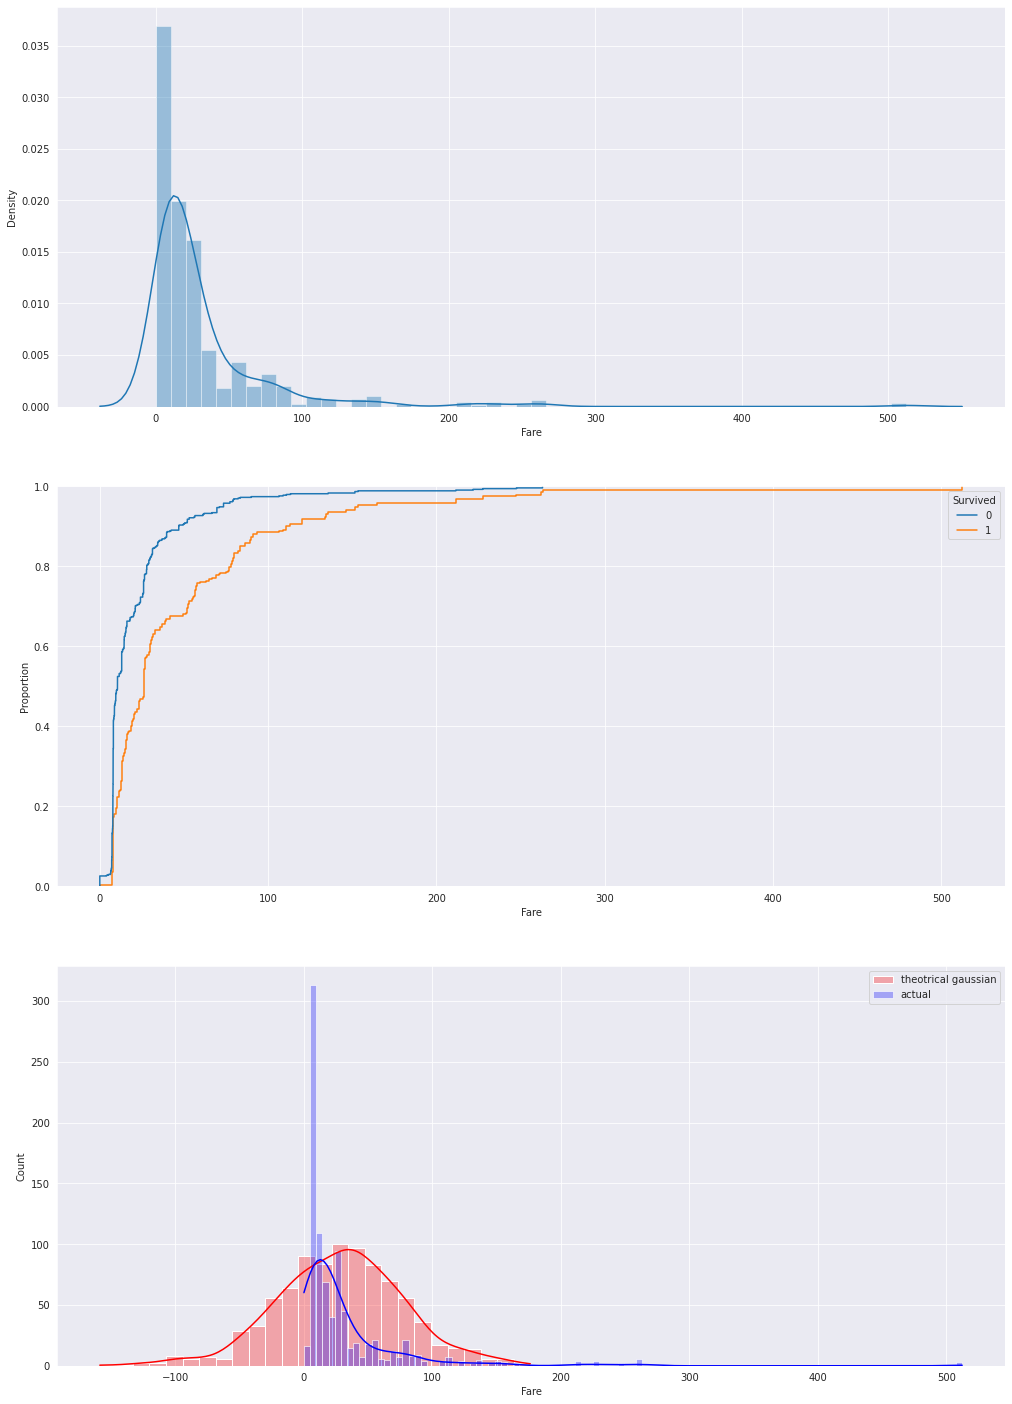

In [11]:
fig,ax=plt.subplots(3,figsize=(17,25))
sns.distplot(train['Fare'],ax=ax[0])              # Actual histogram of Age
sns.ecdfplot(x='Fare',data=train,ax=ax[1],hue='Survived')  #ECDF plot representation of age


#---------------------------------------------------------
std,mean=np.std(train['Fare']),np.mean(train['Fare'])    #Theotrical representation of Fare column
gaussian_Fare=np.random.normal(mean,std,len(train))     # Actual representation of Fare columns

sns.histplot(gaussian_Fare,ax=ax[2],color='red',alpha=0.3,kde=True,label='theotrical gaussian')
sns.histplot(train['Fare'],ax=ax[2],color='blue',alpha=0.3,kde=True,label='actual')
plt.legend()

Conclusion:-
**1.Fare is an exponential curve and need to be change to gaussian.**
**2.We will try to convert it using sqrt function.**

**Correlation Plot**

<AxesSubplot:>

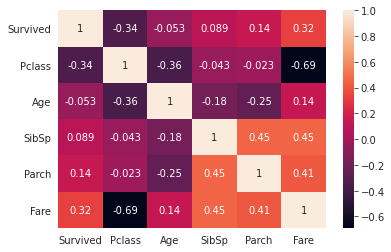

In [12]:
sns.heatmap(train.corr('spearman'),annot=True)


#Pclass and fare  have a strong correlation with Survived.


# **4. Data Manupulation**

In [13]:
#  Categorical to numerical

#------------------------  SEX -----------------------------------------------
train['Sex']=train['Sex'].replace({'male':0,'female':1})
test['Sex']=test['Sex'].replace({'male':0,'female':1}) 
#----------------------- EMBARKED --------------------------------------------
train=pd.get_dummies(train,columns=['Embarked'])
test=pd.get_dummies(test,columns=['Embarked'])


#-----------------Scaling------------------------------------------------------

scale=RobustScaler()     #Robust Scaler is used even if we have outlier in column.
a=train[['Age','Fare']]
scale.fit(data[['Age','Fare']])
train[['Age','Fare']]=scale.transform(a)
test[['Age','Fare']]=scale.transform(test[['Age','Fare']])

# 3. a Faeture Engineering

In [14]:
#--------------  Extracting Title from Name -------------------------------

a=[]
for i in range(len(train['Name'])):
    a.append(train['Name'].iloc[i].split(',')[1].split('.')[0][1:])
train['title']=a
train['title']=train['title'].replace(['Major','Col','Mlle','the Countess','Mme','Lady','Capt','Sir','Don','Jonkheer','Ms'],'Rare')
train['title'].replace({'Mr':1,'Miss':2,'Mrs':3,'Master':4,'Rare':5,'Dr':6,'Rev':6})
#------------------------   Family group --------------------------------------------

train['passenger']=train['SibSp']+train['Parch']+1
def family_group(size):
    a=''
    if(size<=1):
        a='alone'
    elif(size<=3):
        a='small'
    elif(size<=5):
        a='middle'
    elif(size<=7):
        a='large'
    else:
        a='extra_large'
    return a
train['family_group']=train['passenger'].map(family_group)

#-------------------------   Age group ------------------------------------------

def age_group(size):
    a=''
    if(size<=3):
        a='baby'
    elif(size<=13):
        a='child'
    elif(size<=27):
        a='young'
    elif(size<=45):
        a='middle'
    else:
        a='old'
    return a
train['age_group']=data.loc[:len(train),'Age'].map(age_group)






#------------------  Test ------------------------------------------
a=[]
for i in range(len(test['Name'])):
    a.append(test['Name'].iloc[i].split(',')[1].split('.')[0][1:])
test['title']=a
test['title']=test['title'].replace(['Major','Col','Mlle','the Countess','Mme','Lady','Capt','Sir','Don','Jonkheer','Ms','Dona'],'Rare')
test['title'].replace({'Mr':1,'Miss':2,'Mrs':3,'Master':4,'Rare':5,'Dr':6,'Rev':6})

#------------------------------------------------------------------
test['passenger']=test['SibSp']+test['Parch']+1
test['family_group']=test['passenger'].map(family_group)
test['age_group']=data.loc[len(train):,'Age'].map(age_group)



#-------------------------------------------------------------------

train['age_group']=train['age_group'].replace({'old':1,'middle':2,'young':3,'child':4,'baby':5})
test['age_group']=test['age_group'].replace({'old':1,'middle':2,'young':3,'child':4,'baby':5})

#---------------------------------------------------------------------------------------------------------
train['family_group']=train['family_group'].replace({"alone":1,'small':2,'middle':3,'large':4,'extra_large':5})
test['family_group']=test['family_group'].replace({"alone":1,'small':2,'middle':3,'large':4,'extra_large':5})

#------------------------------------------------------------------------------------------------------------

train['title']=train['title'].replace({"Mr":1,'Mrs':2,'Rev':3,'Master':4,'Rare':5,'Miss':2,'Dr':5})
test['title']=test['title'].replace({"Mr":1,'Mrs':2,'Rev':3,'Master':4,'Rare':5,'Miss':2,'Dr':5})

In [15]:
#Dropping useless columns
train.drop(['Name','Ticket','Cabin','SibSp','Parch'],axis=1,inplace=True)    
test.drop(['Name','Ticket','Cabin','SibSp','Parch'],axis=1,inplace=True)

# 5.Model Selection

In [16]:
x=train.drop('Survived',axis=1)
y=train['Survived']


pipeline=Pipeline(steps=[('impute',IterativeImputer(max_iter=30)),('model',LogisticRegression(max_iter=1500))])
cv=RepeatedStratifiedKFold(n_splits=10,n_repeats=3)
score=cross_val_score(pipeline,x,y,cv=cv,scoring='accuracy')


In [17]:
pipeline.fit(x,y)
submit=pd.DataFrame(test.index)
submit['Survived']=pipeline.predict(test)
submit.to_csv('ver1.csv',index=False)

In [18]:
submit

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0
